# **SINGLE CELL ANALYSIS FOR DIET PAPER**

The data in this notebook will be used to generate all analyses for the diet FRP scRNA experiment.

### Last edited: 6/4/2026

### Author: Holly Vose

In [1]:
# STEP 1: Imports
import re
import os
import pprint
import warnings
import scanpy as sc
import anndata as ad
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gprofiler
import gseapy as gp
from gseapy import Biomart
import harmonypy as hm

warnings.filterwarnings('ignore')
sns.set_style("ticks")
sns.set_theme(style="white", context="paper")

In [2]:
# STEP 2: Load Data
adata_filtered = sc.read_h5ad("/projects/hvose@xsede.org/adata_filtered_files/20260604_diet_adata_soupx_refiltered.h5ad")

In [6]:
# STEP 3: Get PCs and batch unmix the data
sc.pp.pca(adata_filtered)
pcs = adata_filtered.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, adata_filtered.obs, "sample")

print("finished harmony")

# Store corrected PCs back in the AnnData object
adata_filtered.obsm['X_pca_harmony'] = harmony_out.Z_corr


2026-06-15 09:40:31,600 - harmonypy - INFO - Running Harmony (PyTorch on cpu)
2026-06-15 09:40:31,601 - harmonypy - INFO -   Parameters:
2026-06-15 09:40:31,601 - harmonypy - INFO -     max_iter_harmony: 10
2026-06-15 09:40:31,601 - harmonypy - INFO -     max_iter_kmeans: 20
2026-06-15 09:40:31,602 - harmonypy - INFO -     epsilon_cluster: 1e-05
2026-06-15 09:40:31,602 - harmonypy - INFO -     epsilon_harmony: 0.0001
2026-06-15 09:40:31,603 - harmonypy - INFO -     nclust: 100
2026-06-15 09:40:31,603 - harmonypy - INFO -     block_size: 0.05
2026-06-15 09:40:31,604 - harmonypy - INFO -     lamb: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
2026-06-15 09:40:31,604 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.]
2026-06-15 09:40:31,605 - harmonypy - INFO -     sigma: [0.1 0.1 0.1 0.1 0.1]...
2026-06-15 09:40:31,605 - harmonypy - INFO -     verbose: True
2026-06-15 09:40:31,606 - harmonypy - INFO -     random_state: 0
2026-06-15 09:40:31,606 - harmon

(109861, 50)


2026-06-15 09:40:33,390 - harmonypy - INFO - KMeans initialization complete.
2026-06-15 09:40:33,526 - harmonypy - INFO - Iteration 1 of 10
2026-06-15 09:40:37,868 - harmonypy - INFO - Iteration 2 of 10
2026-06-15 09:40:42,385 - harmonypy - INFO - Iteration 3 of 10
2026-06-15 09:40:46,820 - harmonypy - INFO - Iteration 4 of 10
2026-06-15 09:40:51,118 - harmonypy - INFO - Iteration 5 of 10
2026-06-15 09:40:55,776 - harmonypy - INFO - Iteration 6 of 10
2026-06-15 09:41:00,409 - harmonypy - INFO - Converged after 6 iterations


finished harmony


In [7]:
# STEP 4: Use the result of harmony to properly recluster the data
sc.pp.neighbors(adata_filtered, use_rep='X_pca_harmony')
sc.tl.umap(adata_filtered)

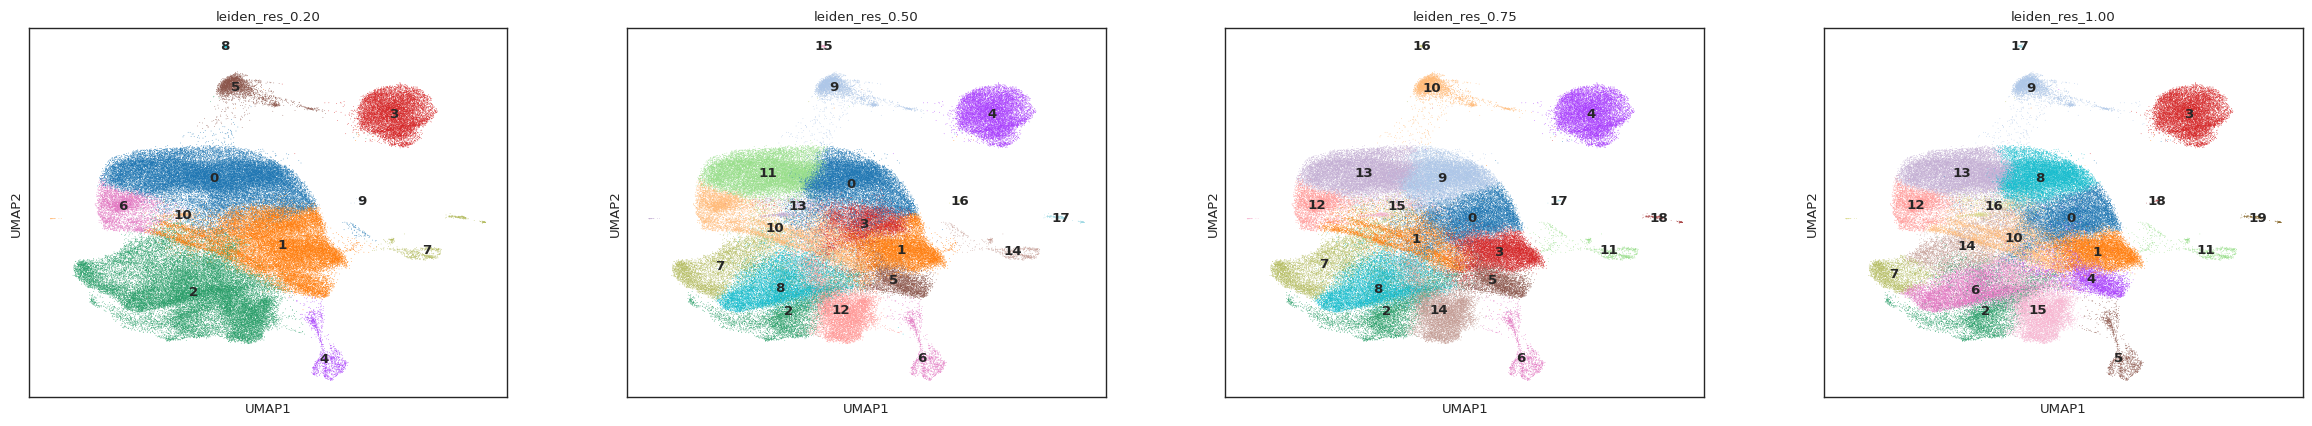

In [9]:
# STEP 5: Generate different resolutions of our clustering to determine proper scale

for res in [0.2, 0.5, 0.75, 1]:
    sc.tl.leiden(adata_filtered, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    adata_filtered,
    color=["leiden_res_0.20", "leiden_res_0.50", "leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
) 

In [10]:
#STEP 6: LOAD COLOR PALETTES
infected_colors = {
    "5DPI": "#e88048",
    "Mock": "#582B36"
}

cluster_colors = ["#2E52A3",
                  "#004100",
                  "#582B36",
                  "#E2552D",
                  "#009499",
                  "#E3BD33",
                  "#09094A",
                  "#C67FAE",
                  "#A6BE47",
                  "#BAA5FF",
                  "#FDD5A1",
                  ]

extra_cluster_colors = ["#6D5698",
                        "#98DDDF",
                        "#A00239"
                       ]

extra_extra_cluster_colors = [
                  "#AC6C29",
                  "#333AFB",
                  "#10BCFE",
                  "#012731",
                  
                  "#F53C9F",
                  "#B623CC",
                  "#D7E8BC",
                  "#BAA5FF",
]

i_contrast_colors = ["#E2552D","#2E5283"]
ifitm_hex = ["#BEBDBD", "#DF3848"]
dp_hex = ["#FFFFFF","#0075B8"]
aggressive_hex = ["#FFFFFF","#000000"]

ifitm_cmap = mcolors.LinearSegmentedColormap.from_list("ifitm_cmap",ifitm_hex)
aggr_cmap = mcolors.LinearSegmentedColormap.from_list("aggr_cmap",aggressive_hex)
dp_cmap = mcolors.LinearSegmentedColormap.from_list("dp_cmap",dp_hex)

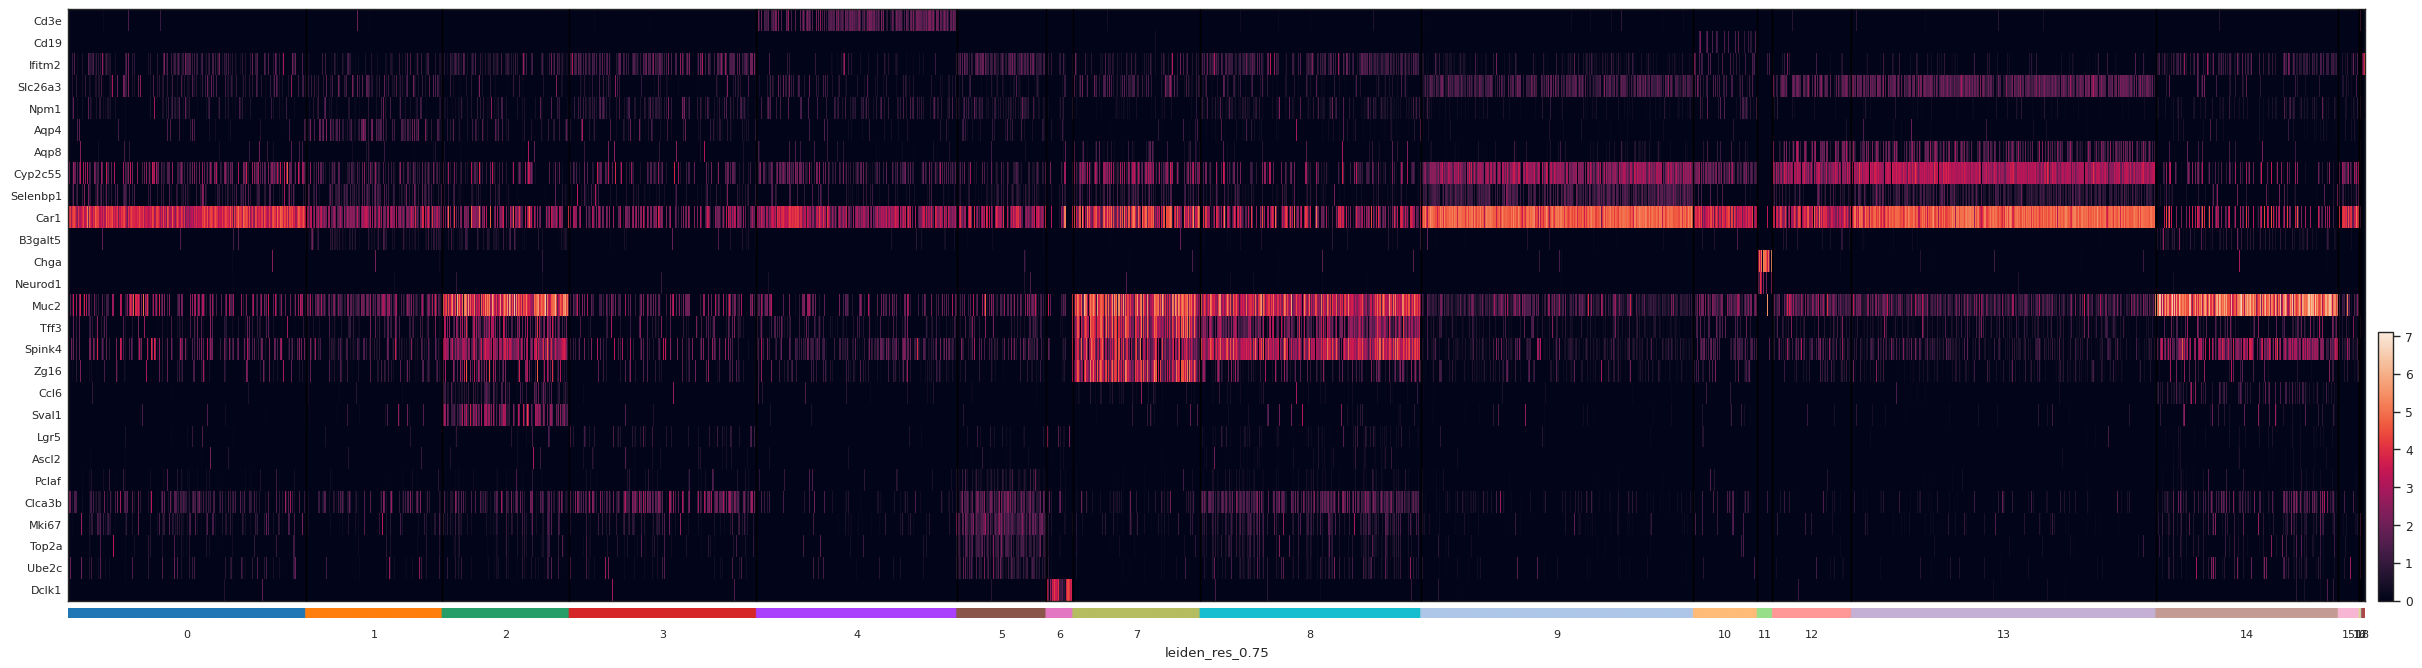

In [11]:
#plot a heatmap of given markers to assess cluster identity
markers = ["Cd3e","Cd19","Ifitm2","Slc26a3", "Npm1", "Aqp4", "Aqp8", "Cyp2c55", "Selenbp1", "Car1", "B3galt5", "Chga", "Neurod1", "Muc2", "Tff3", "Spink4", "Zg16", "Ccl6", "Sval1", "Lgr5", "Ascl2", "Pclaf", "Clca3b","Mki67", "Top2a", "Ube2c", "Dclk1"]

sc.pl.heatmap(adata_filtered,markers,groupby="leiden_res_0.75",figsize=(30,8),swap_axes=True)

In [ ]:
# STEP 7 (optional): Save reclustered data to a new h5ad file
adata_diet_filtered.write_h5ad("20260423_diet_hm_recluster.h5ad")

## ANALYSIS ##

**The analyses below include:**

### SUB-CLUSTERING
- T Cells (Cd3e+)
- B Cells (Cd19+/Cd79+)
- Epcam+ Cells (not including T/B cells)

### DIFFERENTIALLY EXPRESSED GENES
- Upregulated in amp (compared to MHVY)
- Upregulated in no_fiber (compared to MHVY)
- Overlapping upregulated in amp and no_fiber (compared to MHVY)

### PATHWAY ANALYSIS
- DEG lists generated in the DEG section

## **INITIAL DEFINITIONS**

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(adata_diet_filtered, groupby="leiden_res_0.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    adata_diet_filtered, groupby="leiden_res_0.50", standard_scale="var", n_genes=5
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

diet_annotation = {
    "0": "Absorptive Colonocytes",
    "1": "Absorptive Colonocytes",
    "2": "Goblet Cells", 
    "3": "Absorptive Colonocytes", 
    "4": "T Cells", 
    "5": "Transit Amplifying Cells",
    "6": "Goblet Cells",
    "7": "Tuft Cells",
    "8": "Goblet Cells",
    "9": "Goblet Cells",
    "10": "B Cells",
    "11": "Goblet Cells",
    "12": "Absorptive Colonocytes",
    "13": "Enteroendocrine Cells",
    "14": "Macrophages",
    "15": "T Cells", 
    "16": "Absorptive Colonocytes (special)",
}

adata_diet_filtered.obs['cluster_cell_type'] = adata_diet_filtered.obs["leiden_res_0.50"].map(diet_annotation).astype('category')

In [ ]:
sc.pl.umap(adata_diet_filtered,color="cluster_cell_type",palette=cluster_colors)
sc.pl.umap(adata_diet_filtered,color="leiden_res_0.50",palette=cluster_colors)
sc.pl.umap(adata_diet_filtered,color="Lgr5",cmap=ifitm_cmap)
sc.pl.umap(adata_diet_filtered,color="Krt20",cmap=ifitm_cmap)
sc.pl.umap(adata_diet_filtered,color="Mki67",cmap=ifitm_cmap)

## **SUB-CLUSTERING**

In [ ]:
#GENERATE COPIES FOR EACH INDIVIDUAL UMAP
#cd3 = adata_diet_filtered[:,'Spink4'].X

t_cell_subset = adata_diet_filtered[
    (adata_diet_filtered[:,'Cd3e'].X.toarray() > 0.5) &
    (adata_diet_filtered[:,'Cd3d'].X.toarray() > 0.5) &
    (adata_diet_filtered[:,'Cd3g'].X.toarray() > 0.5) &
    (adata_diet_filtered[:,'Cd247'].X.toarray() > 0.5)
    ].copy()

b_cell_subset = adata_diet_filtered[
    (adata_diet_filtered[:,'Cd19'].X.toarray() > 0.5) &
    (adata_diet_filtered[:,'Cd79a'].X.toarray() > 0.5) &
    (adata_diet_filtered[:,'Cldn7'].X.toarray() < 0.01)
    ].copy()

t_and_b_cell_subset = adata_diet_filtered[
    (adata_diet_filtered[:,'Ptprc'].X.toarray() > 0.5)
    ].copy()

epcam_subset = adata_diet_filtered[
    (adata_diet_filtered[:,'Epcam'].X.toarray() > 0.25) &
    (adata_diet_filtered[:, 'Ptprc'].X.toarray() < 0.01) &
    (adata_diet_filtered[:,'Cd79a'].X.toarray() < 0.01) &
    (adata_diet_filtered[:, 'Cd19'].X.toarray() < 0.01) &
    (adata_diet_filtered[:,'Cd3e'].X.toarray() < 0.01) &
    (adata_diet_filtered[:,'Cd3d'].X.toarray() < 0.01) &
    (adata_diet_filtered[:,'Cd3g'].X.toarray() < 0.01) &
    (adata_diet_filtered[:,'Cd247'].X.toarray() < 0.01) &
    (adata_diet_filtered[:, 'Ighm'].X.toarray() < 0.01)
].copy()
# if isinstance(cd3, (np.ndarray, list)):
#     #for dense arrays or lists
#     mask = muc.flatten() > 0
# else:
#     # For sparse matrices (e.g., csr_matrix)
#     mask = (cd3.toarray().flatten() > 0)

# adata_subset_view = adata_diet_filtered[~mask, :]

# adata_cd3_diet = adata_subset_view.copy()
#adata_cd3_diet_filteredf = adata_cd3_diet_filtered[adata_cd3_diet_filtered.obs['leiden_res_0.20'].isin(['0','1','3'])].copy()
print(t_cell_subset)
print(b_cell_subset)
print(epcam_subset)

## **T AND B CELL SUBSET**

In [ ]:
sc.pp.neighbors(t_and_b_cell_subset)
sc.tl.umap(t_and_b_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(t_and_b_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    t_and_b_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(t_and_b_cell_subset, groupby="leiden_res_1.00", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    t_and_b_cell_subset, groupby="leiden_res_1.00", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
sc.pl.umap(t_and_b_cell_subset, color="Ptprc",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd3e",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd8a",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd79a",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Dclk1",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Ncf2",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Cd74",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Mki67",cmap=ifitm_cmap)
sc.pl.umap(t_and_b_cell_subset, color="Ncr1",cmap=ifitm_cmap)

## **T CELL SUBSET**

In [ ]:
sc.pp.neighbors(t_cell_subset)
sc.tl.umap(t_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0]:
    sc.tl.leiden(t_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    t_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(t_cell_subset, color="treatment")

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(t_cell_subset, groupby="leiden_res_0.20", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    t_cell_subset, groupby="leiden_res_0.20", standard_scale="var", n_genes=5, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
t_cell_annotation = {
    "0": "CD8 T Cells",
    "1": "CD4/CD8 T Cells",
    "2": "Pre-T Cells (CD7+)"
}

t_cell_subset.obs['cluster_cell_type'] = t_cell_subset.obs["leiden_res_0.20"].map(t_cell_annotation).astype('category')

In [ ]:
sc.pl.umap(t_cell_subset, color="Cd7",cmap=ifitm_cmap,frameon=False)
sc.pl.umap(t_cell_subset, color="treatment", palette=extra_cluster_colors,frameon=False,save='/diet/t_cell_treatment_umap.svg')
sc.pl.umap(t_cell_subset, color="cluster_cell_type", palette=extra_cluster_colors,frameon=False,save='/diet/t_cell_subset_umap.svg')

In [ ]:
genes_to_gen = ['Cd8a','Cd4','Cd7','Cd8b1','Cd3e']

In [ ]:
for gene in genes_to_gen:
    sc.pl.umap(t_cell_subset, color=gene, cmap=ifitm_cmap, frameon=False, save=f'/diet/t_cell_{gene}.svg')

In [ ]:
sc.tl.rank_genes_groups(t_cell_subset, groupby="treatment", group="amp", method='wilcoxon',reference="MHVY",key_added="diet_IEL_amp")
sc.tl.rank_genes_groups(t_cell_subset, groupby="treatment", group="no_fiber", method='wilcoxon',reference="MHVY",key_added="diet_IEL_nf")
sc.get.rank_genes_groups_df(t_cell_subset,key="diet_IEL_amp").to_csv("20260417_tcell_amp_deg.csv",index=False)
sc.get.rank_genes_groups_df(t_cell_subset,key="diet_IEL_nf").to_csv("20260417_tcell_nf_deg.csv",index=False)

## **B CELL SUBSET**

In [ ]:
sc.pp.neighbors(b_cell_subset)
sc.tl.umap(b_cell_subset)

In [ ]:
for res in [0.02, 0.1, 0.4, 0.5, 0.75, 1.0]:
    sc.tl.leiden(b_cell_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    b_cell_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.40", "leiden_res_0.50","leiden_res_0.75","leiden_res_1.00"],
    legend_loc="on data",
)
sc.pl.umap(b_cell_subset,color="treatment")

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(b_cell_subset, groupby="leiden_res_0.40", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    b_cell_subset, groupby="leiden_res_0.40", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
b_cell_annotation = {
    "0": "Naive B Cells"
}

b_cell_subset.obs['cluster_cell_type'] = b_cell_subset.obs["leiden_res_0.20"].map(b_cell_annotation).astype('category')

In [ ]:
#sc.pl.umap(b_cell_subset, color="cluster_cell_type",palette=extra_extra_cluster_colors,frameon=False,save="b_cell_cluster_cell_type.svg")
sc.pl.umap(b_cell_subset, color="Tlr9",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Tlr9.svg')
sc.pl.umap(b_cell_subset, color="Ms4a1",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ms4a1_CD20.svg')
sc.pl.umap(b_cell_subset, color="Ighm",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ighm.svg')
sc.pl.umap(b_cell_subset, color="Ighd",cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Ighd.svg')
sc.pl.umap(b_cell_subset, title="Fcer2", cmap=ifitm_cmap,frameon=False,save='/diet/b_cell_Fcer2_CD23.svg')
sc.pl.umap(b_cell_subset, color="cluster_cell_type",palette=extra_extra_cluster_colors,frameon=False,save='/diet/b_cell_subset_umap.svg')
sc.pl.umap(b_cell_subset, color="treatment",palette=extra_extra_cluster_colors,frameon=False,save='/diet/b_cell_treatment_umap.svg')

In [ ]:
sc.tl.rank_genes_groups(b_cell_subset, groupby="treatment", group="amp", method='wilcoxon',reference="MHVY",key_added="diet_IEL_amp")
sc.tl.rank_genes_groups(b_cell_subset, groupby="treatment", group="no_fiber", method='wilcoxon',reference="MHVY",key_added="diet_IEL_nf")
sc.get.rank_genes_groups_df(b_cell_subset,group="amp",key="diet_IEL_amp").to_csv("20260417_bcell_amp_deg.csv",index=False)
sc.get.rank_genes_groups_df(b_cell_subset,group="no_fiber",key="diet_IEL_nf").to_csv("20260417_bcell_nf_deg.csv",index=False)

## **EPCAM SUBSET**

In [ ]:
sc.pp.pca(epcam_subset)

In [ ]:
# Get PCs from the AnnData object
pcs = epcam_subset.obsm['X_pca']
print(pcs.shape)  # (n_cells, n_pcs)

# Run Harmony on the PCA embedding
harmony_out = hm.run_harmony(pcs, epcam_subset.obs, "treatment")

print("finished harmony")

# Store corrected PCs back in the AnnData object
epcam_subset.obsm['X_pca_harmony'] = harmony_out.Z_corr


In [ ]:
# Use harmonized PCs for downstream analysis
sc.pp.neighbors(epcam_subset, use_rep='X_pca_harmony')
sc.tl.umap(epcam_subset)
sc.tl.leiden(epcam_subset)

In [ ]:
for res in [0.02, 0.1, 0.2, 0.5, 0.75, 1.0, 1.5]:
    sc.tl.leiden(epcam_subset, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

sc.pl.umap(
    epcam_subset,
    color=["leiden_res_0.02", "leiden_res_0.10", "leiden_res_0.20", "leiden_res_0.50","leiden_res_1.00","leiden_res_1.50"],
    legend_loc="on data",
)
sc.pl.umap(
    epcam_subset,
    color="treatment"
)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="leiden_res_1.50", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="leiden_res_1.50", standard_scale="var", n_genes=5, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#CLUSTER DEFINITIONS
#Stem Cell: Lgr5+, Ascl2+, Muc2-, Lrig1+ (ideally)
#Tuft Cell: Dclk1+
#Colonocytes: Slc26a3+, Krt20+, Aqp8+
#TA Cells: Foxm1, Ube2c+
#Goblet Cell Progenitor: Spdef+, Atoh1+
#Goblet Cell: Reg4+, Spink4+, Tff3+, Fad3+
#Immune Signaling Cells: B2m+, Cd3g+
#EC Progenitors: B3galt5+
#Actin-Associated Genes: Actb+, Car1, Krt8

diet_annotation = {
    "0": "Absorptive Progenitors",
    "1": "Absorptive Colonocytes",
    "2": "Aging Goblet Cells", 
    "3": "Stem Cells", 
    "4": "Goblet Cells", 
    "5": "Deep-crypt Goblet Cell",
    "6": "Goblet Cells",
    "7": "Goblet Cells",
    "8": "Absorptive Progenitors",
    "9": "Deep-crypt Goblet Cell",
    "10": "Absorptive Progenitors",
    "11": "Absorptive Colonocytes",
    "12": "Aging Goblet Cells",
    "13": "Absorptive Colonocytes",
    "14": "Goblet Cells",
    "15": "Secretory Progenitors",
    "16": "Transit Amplifying Cells",
    "17": "Absorptive Colonocytes",
    "18": "Absorptive Colonocytes",
    "19": "Absorptive Colonocytes",
    "20": "Absorptive Colonocytes",
    "21": "Absorptive Colonocytes",
    "22": "Enteroendocrine Cells",
    "23": "Absorptive Colonocytes",
    "24": "Goblet Cells",
    "25": "Tuft Cells",
    "26": "Macrophages",
    "27": "Absorptive Colonocytes",
    "28": "Absorptive Colonocytes",
    "29": "Absorptive Colonocytes"
}
epcam_subset.obs['cluster_cell_type'] = epcam_subset.obs["leiden_res_1.50"].map(diet_annotation).astype('category')

In [ ]:
genes_to_gen = ['Lgr5','Ascl2','Mki67','Top2a','Slc26a3','Aqp8','Aqp4','Hes1','Muc2','Krt20','Spink4','Reg4','Neurod1','Chga','Dclk1','Atoh1','Ly6a','Rac2','Sval1']

In [ ]:
for gene in genes_to_gen:
    sc.pl.umap(epcam_subset, color=gene, cmap=ifitm_cmap, frameon=False, title=f"{gene}_diet",save=f"/diet/{gene}.svg")

In [ ]:
del df
del dfa

In [ ]:
dfa = epcam_subset.to_df()
# Create boolean for co-expression (e.g., Gene1 > 0 AND Gene2 > 0)
co_expr = (dfa['Krt20'] == 0) & (dfa['Muc2'] > 0.5)
# Add back to metadata
epcam_subset.obs['co_expression'] = co_expr.astype(str)
# Plot cells with both genes
sc.pl.umap(epcam_subset, color='co_expression')

In [ ]:
gene_name = 'Muc2'
cluster_id = 'True'
cluster_col = 'co_expression'

# Get data for the gene and cluster
df = sc.get.obs_df(epcam_subset, keys=[cluster_col, gene_name])

# Calculate average
avg_expr = df.groupby(cluster_col)[gene_name].mean()[cluster_id]
print(f"Average expression of {gene_name} in cluster {cluster_id}: {avg_expr}")

In [ ]:
#sc.pl.umap(epcam_subset,color="cluster_cell_type",palette=cluster_colors,frameon=False, title="",save="cluster_cell_type.svg")
sc.pl.umap(epcam_subset,color="leiden_res_1.50",palette=cluster_colors,frameon=False,legend_loc="on data")
sc.pl.umap(epcam_subset,color="cluster_cell_type",palette=cluster_colors,frameon=False,save="/diet/full_umap.svg")
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="MHVY"))
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="no_fiber"))
# sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs["treatment"]=="amp"))
#sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs['cluster_cell_type']=="Absorptive Colonocytes"))
#sc.pl.umap(epcam_subset,color="Muc2",cmap=ifitm_cmap,mask_obs=(epcam_subset.obs['cluster_cell_type']=="Goblet Cells"))
sc.pl.umap(epcam_subset,color="Sval1",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Phgr1",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Alpi",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="Aqp8",cmap=ifitm_cmap)
sc.pl.umap(epcam_subset,color="treatment",palette=cluster_colors,mask_obs=(epcam_subset.obs["treatment"]=="MHVY"))
sc.pl.umap(epcam_subset,color="Krt8",cmap=ifitm_cmap)

In [ ]:
#Preprocessing: find most differentially expressed genes per cluster
sc.tl.rank_genes_groups(epcam_subset, groupby="cluster_cell_type", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(
    epcam_subset, groupby="cluster_cell_type", standard_scale="var", n_genes=10, dendrogram=False
)

#if save is desired, can add save="leiden_dotplot.svg" to parameters

In [ ]:
#generate a DEG list of a specific cluster comparing two specific conditions
diet_clusters = epcam_subset.obs["cluster_cell_type"].cat.categories.tolist()

amp_overlap = []
nf_overlap = []
total_overlap = []

with open("diet_epcam_gene_lists.txt","w",encoding="utf-8") as f:
    for vclus in diet_clusters:
        amp_up = epcam_subset[(epcam_subset.obs["treatment"].isin(["MHVY","amp"])) & (epcam_subset.obs["cluster_cell_type"] == vclus)]
        nf_up = epcam_subset[(epcam_subset.obs["treatment"].isin(["MHVY","no_fiber"])) & (epcam_subset.obs["cluster_cell_type"] == vclus)]
        if (amp_up[amp_up.obs['treatment']=="amp"].n_obs > 1) and (amp_up[amp_up.obs['treatment']=="MHVY"].n_obs > 1):
            sc.tl.rank_genes_groups(amp_up, groupby="treatment", group="amp",method='wilcoxon',reference="MHVY",key_added=f"amp_{vclus}")
            df_amp = sc.get.rank_genes_groups_df(amp_up, group="amp",key=f"amp_{vclus}")
            if (nf_up[nf_up.obs['treatment']=="no_fiber"].n_obs > 1) and (nf_up[nf_up.obs['treatment']=="MHVY"].n_obs > 1): 
                sc.tl.rank_genes_groups(nf_up, groupby="treatment", group="no_fiber", method='wilcoxon',reference="MHVY",key_added=f"nf_{vclus}")
                df_nf = sc.get.rank_genes_groups_df(nf_up, group="no_fiber",key=f"nf_{vclus}")

                title_fix = re.search(r"(.+) (.+)",vclus)

                if title_fix is not None:
                    df_amp.to_csv(f"amp_{title_fix.group(1)}_{title_fix.group(2)}.csv",index=False)
                    df_nf.to_csv(f"nf_{title_fix.group(1)}_{title_fix.group(2)}.csv",index=False)
                else:
                    df_amp.to_csv(f"amp_{vclus}.csv",index=False)
                    df_nf.to_csv(f"nf_{vclus}.csv",index=False)
            
                amp_up = df_amp[(df_amp['pvals_adj'] < 0.05) & (df_amp['logfoldchanges'] > 0)]
                amp_dw = df_amp[(df_amp['pvals_adj'] < 0.05) & (df_amp['logfoldchanges'] < 0)]
                nf_up = df_nf[(df_nf['pvals_adj'] < 0.05) & (df_nf['logfoldchanges'] > 0)]
                nf_dw = df_nf[(df_nf['pvals_adj'] < 0.05) & (df_nf['logfoldchanges'] < 0)]
            
                combined_up = amp_up.loc[(amp_up['names'].isin(nf_up['names']))]
                combined_dw = amp_dw.loc[(amp_dw['names'].isin(nf_dw['names']))]
                amp_up_only = amp_up.loc[~(amp_up['names'].isin(nf_up['names']))]
                amp_dw_only = amp_dw.loc[~(amp_dw['names'].isin(nf_dw['names']))]
                nf_up_only = nf_up.loc[~(nf_up['names'].isin(amp_up['names']))]
                nf_dw_only = nf_dw.loc[~(nf_dw['names'].isin(amp_dw['names']))]
    
                # title = f"/publication_data/{vclus}_{}"
                f.write(f"COMBINED UP FOR {vclus}:\n")
                f.write(f"{str(combined_up['names'].tolist())}\n")
                f.write(f"COMBINED DW FOR {vclus}:\n")
                f.write(f"{str(combined_dw['names'].tolist())}\n")
                f.write(f"AMP UP ONLY FOR {vclus}:\n")
                f.write(f"{str(amp_up_only['names'].tolist())}\n")
                f.write(f"AMP DW ONLY FOR {vclus}:\n")
                f.write(f"{str(amp_dw_only['names'].tolist())}\n")
                f.write(f"NO FIBER UP ONLY FOR {vclus}:\n")
                f.write(f"{str(nf_up_only['names'].tolist())}\n")
                f.write(f"NO FIBER DW ONLY FOR {vclus}:\n")
                f.write(f"{str(nf_dw_only['names'].tolist())}\n")
                
            else:
                print(f"NF cluster not valid, less than 1 sample detected for {vclus}")
        
            # print(f"CLUSTER {vclus}:")
            #print(f"Out of {len(sig_df_vg_mhvy_up)} total MHVY-up genes, {len(sig_df_vg_mhvy_dw)} total MHVY-down genes, {len(sig_df_vg_dhe_up)} total dHE-up genes, and {len(sig_df_vg_dhe_dw)} total dHE-down genes")
            # print(f"COMBINED UPREGULATED: {len(vg_combined_up['names'])}")
            # print(vg_combined_up['names'].tolist())
            # print(f"MHVY ONLY: {len(vg_mhvy_up_only['names'])}")
            # print(vg_mhvy_up_only['names'].tolist())
            # print(f"dHE ONLY: {len(vg_dhe_up_only['names'])}")
            # print(vg_dhe_up_only['names'].tolist())
            # combined_vals.append(len(vg_combined_up['names']))
            # mhvy_only_vals.append(len(vg_mhvy_up_only['names']))
            # dhe_only_vals.append(len(vg_dhe_up_only['names']))
        else:
            print(f"Cannot calculate for cluster {vclus} because 1 or fewer samples were detected.")
            
        
